In [11]:
import os
import cv2
import copy

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import KDTree

from skimage.morphology import skeletonize

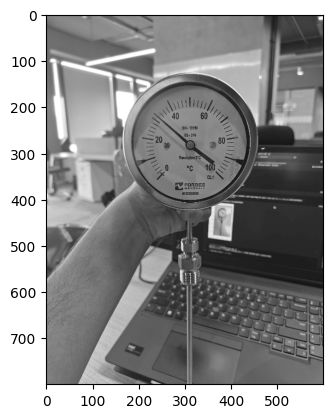

In [12]:
image_dir_path = "./"

gray_img = cv2.resize(cv2.cvtColor(rgb_img:=cv2.imread(os.path.join(image_dir_path,"IMG20251113123750.jpg"))[:,:,::-1],cv2.COLOR_RGB2GRAY),(600,800))
plt.imshow(gray_img,cmap='grey')

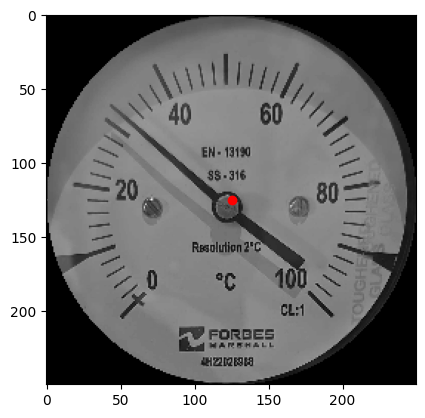

In [13]:
# detecting circle part
gray_blur = cv2.medianBlur(gray_img, 9)
detected_circles = cv2.HoughCircles(gray_blur,cv2.HOUGH_GRADIENT,dp=1.5,minDist=100)

if detected_circles is not None:
    
    detected_circles = detected_circles.astype(np.int32)
    max_radius_circle = detected_circles[0][0]
    center_x,center_y,radius = max_radius_circle

    mask = np.zeros_like(gray_img)
    cv2.circle(mask,(center_x,center_y),radius, 255, -1)
    masked_dial = cv2.bitwise_and(gray_img,gray_img,mask=mask)

    padding = min(150,radius)
    y1, y2 = max(center_y - padding, 0), min(center_y + padding, gray_img.shape[0])
    x1, x2 = max(center_x - padding, 0), min(center_x + padding, gray_img.shape[1])
    detected_dial = masked_dial[y1:y2, x1:x2]

    center_x -= x1
    center_y -= y1

    plt.imshow(detected_dial,cmap='grey')
    plt.scatter(center_x,center_y,color='red')
    plt.show()



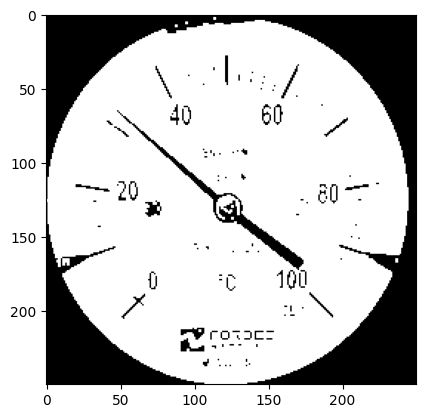

In [14]:
# little preprocessing 

_, thresh_binary = cv2.threshold(detected_dial, 90, 255, cv2.THRESH_BINARY)
dilated_thresh = cv2.dilate(thresh_binary,kernel=np.ones((2,2),np.uint8))
plt.imshow(dilated_thresh,cmap='grey')
plt.show()

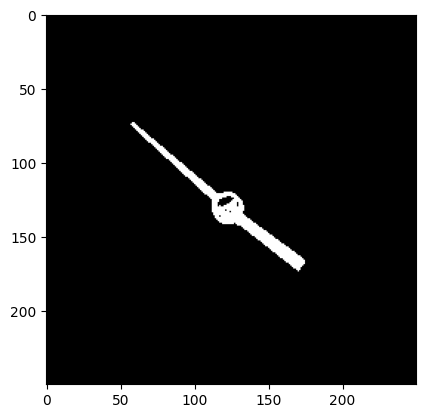

In [15]:
# finding nearby and biggest contour to center

contours, hierarchy = cv2.findContours(dilated_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

max_area, best_contour, closest_distance = 0, None, float('inf')

distance_threshold = 50  

for contour in contours:
    pts = contour.reshape(-1, 2)
    tree = KDTree(pts)
    dist, idx = tree.query(np.array([center_x, center_y]))
    
    area = cv2.contourArea(contour)
    
    if dist < distance_threshold:
        if area > max_area:
            max_area = area
            best_contour = contour
            closest_distance = dist


current_pointer_mask = np.zeros_like(detected_dial)

cv2.drawContours(current_pointer_mask, [best_contour], -1, color=255, thickness=cv2.FILLED)
plt.imshow(current_pointer_mask,cmap='grey')
plt.show()

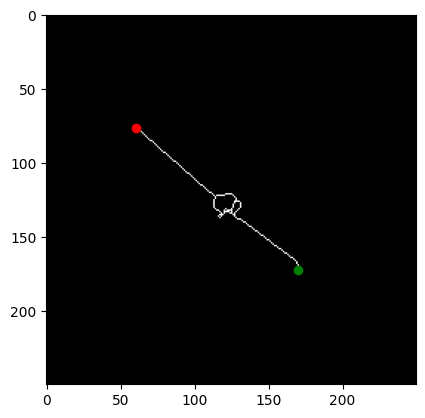

In [16]:
# skeletonizing and finding angle to base


def eucliden_dist(x1,y1,x2,y2):
    return ((y2-y1)**2 + (x2-x1)**2)**0.5

current_pointer_skel = skeletonize(current_pointer_mask)
ys, xs = np.where(current_pointer_skel)

# extreme 1 : distant point from center
e1_index = np.argmax(eucliden_dist(xs,ys,center_x,center_y))
e1_x, e1_y = xs[e1_index], ys[e1_index]

# extreme 2 : distant point from extreme 1
e2_index = np.argmax(eucliden_dist(xs,ys,e1_x,e1_y))
e2_x, e2_y = xs[e2_index], ys[e2_index]

plt.imshow(current_pointer_skel, cmap="gray")
plt.scatter(e1_x,e1_y, color='red')  
plt.scatter(e2_x,e2_y, color='green')  

plt.show()


In [ ]:
def get_angle(slope : float):
    return np.rad2deg(np.arctan(slope)) % 180

def get_slope(x1,y1,x2,y2):
    return (y2-y1)/(x2-x1 + 1e-6) 


def get_value_pointed(angle):

    # mapper : 0 deg -> 18 ; 180 deg -> 82
    return ((82-18)/(180 - 0))*angle + 17 


slope = get_slope(e1_x,e1_y,e2_x,e2_y)
angle = get_angle(slope)
value = get_value_pointed(angle)
print('angle : %f | estimated value : %f'%(angle,value))

angle : 41.112090 | estimated value : 31.617632


## Let's test it on other images

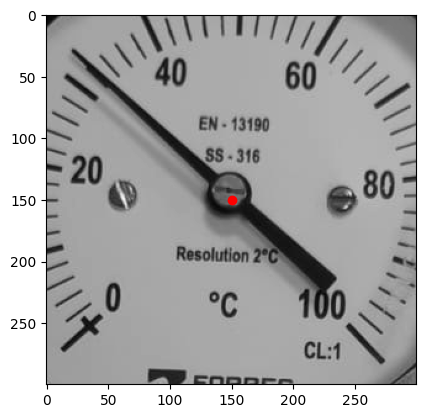

angle : 44.283840 | estimated value : 32.745365


In [18]:
def get_angle(slope : float):
    return np.rad2deg(np.arctan(slope)) % 180

def get_slope(x1,y1,x2,y2):
    return (y2-y1)/(x2-x1 + 1e-6) 

def eucliden_dist(x1,y1,x2,y2):
    return ((y2-y1)**2 + (x2-x1)**2)**0.5

def get_value_pointed(angle):

    # mapper : 0 deg -> 18 ; 180 deg -> 82
    return ((82-18)/(180 - 0))*angle + 17  


def detect_value_pointed(image_path : str, padding : int):
    
    # print(image_path)
    gray_img = cv2.cvtColor(rgb_img:=cv2.imread(image_path)[:,:,::-1],cv2.COLOR_RGB2GRAY)
    # detecting circle part
    gray_blur = cv2.medianBlur(gray_img, 9)
    detected_circles = cv2.HoughCircles(gray_blur,cv2.HOUGH_GRADIENT,dp=1.5,minDist=100)

    if detected_circles is not None:
        
        detected_circles = detected_circles.astype(np.int32)
        max_radius_circle = detected_circles[0][0]
        center_x,center_y,radius = max_radius_circle

        mask = np.zeros_like(gray_img)
        cv2.circle(mask,(center_x,center_y),radius, 255, -1)
        masked_dial = cv2.bitwise_and(gray_img,gray_img,mask=mask)

        padding = min(150,radius)
        y1, y2 = max(center_y - padding, 0), min(center_y + padding, gray_img.shape[0])
        x1, x2 = max(center_x - padding, 0), min(center_x + padding, gray_img.shape[1])
        detected_dial = masked_dial[y1:y2, x1:x2]

        center_x -= x1
        center_y -= y1

        _, thresh_binary = cv2.threshold(detected_dial, 120, 200, cv2.THRESH_BINARY)
        dilated_thresh = cv2.dilate(thresh_binary,kernel=np.ones((5,5),np.uint8))

        contours, _ = cv2.findContours(dilated_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

        max_area, best_contour, closest_distance = 0, None, float('inf')
        distance_threshold = 50
        for contour in contours:
            pts = contour.reshape(-1, 2)
            tree = KDTree(pts)
            dist, idx = tree.query(np.array([center_x, center_y]))
            
            area = cv2.contourArea(contour)
            
            if dist < distance_threshold:
                if area > max_area:
                    max_area = area
                    best_contour = contour

        current_pointer_mask = np.zeros_like(detected_dial)
        cv2.drawContours(current_pointer_mask, [best_contour], -1, color=255, thickness=cv2.FILLED)

        current_pointer_skel = skeletonize(current_pointer_mask)
        ys, xs = np.where(current_pointer_skel)

        # extreme 1 : distant point from center
        e1_index = np.argmax(eucliden_dist(xs,ys,center_x,center_y))
        e1_x, e1_y = xs[e1_index], ys[e1_index]

        # extreme 2 : distant point from extreme 1
        e2_index = np.argmax(eucliden_dist(xs,ys,e1_x,e1_y))
        e2_x, e2_y = xs[e2_index], ys[e2_index]

        slope = get_slope(e1_x,e1_y,e2_x,e2_y)
        angle = get_angle(slope)
        value = get_value_pointed(angle)
        plt.imshow(detected_dial,cmap='grey')
        plt.scatter(center_x,center_y,color='red')

        plt.show()

        return angle,value
    
    return 0,0
        

angle, value = detect_value_pointed(image_path=os.path.join(image_dir_path,'image.jpg'),padding=150)
print('angle : %f | estimated value : %f'%(angle,value))

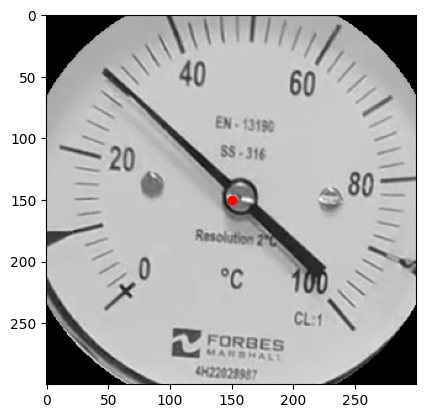

angle : 38.047043 | estimated value : 30.527837


In [19]:
# center is not stable here because of orientation

angle, value = detect_value_pointed(image_path=os.path.join(image_dir_path,'image_4.png'),padding=150)
print('angle : %f | estimated value : %f'%(angle,value))